# The layered prior: PEST setup with `PstFrom`

In [the previous notebook](../part1_01_build_model/dizon_build_model.ipynb) we built the DIZON reactive-transport model and ran it once — a single forward run costs roughly **6 minutes** on a laptop. That cost is the whole reason this curriculum exists: a model this expensive cannot be wrapped in the kind of brute-force ensemble workflows we would reach for with a cheap model. Before we worry about emulation, though, we need to tell PEST++ what is *uncertain* about this model and how it is allowed to vary. That is what this notebook does.

We use [`pyemu`](https://github.com/pypest/pyemu)'s `PstFrom` helper to build a PEST interface around the model: template files (which parameters PEST++ may change), instruction files (which model outputs PEST++ should read), and a control file (`pest.pst`) that ties them together. If you have not met template/instruction/control files before, the [intro to PEST and IES](../part0_04_intro_to_pest_and_ies/) notebook walks through the model-as-black-box contract.

The narrative spine of this notebook is the **layered prior**. Reactive-transport uncertainty is not just K-fields. We parameterise the model in three tiers, and each tier gets its own section below:

1. **Flow** — hydraulic conductivity.
2. **Transport** — porosity and (pending verification) longitudinal dispersivity.
3. **Reaction** — pyrite abundance (and, we will see, the pyrite *oxidation rate*, which turns out not to be templatable here).

We deliberately leave some things *out* of the prior, and we will say why as we go. The point of the tiers is pedagogical: by the end you should see that the case's signature uncertainty lives in the reaction tier, not the flow tier.

### Admin

First the imports. We assert that `flopy` and `pyemu` resolve to the vendored copies in `dependencies/` (the same versions the whole curriculum was built and tested against), then add the parent `tutorials/` directory to the path so we can import the shared helper module, `herebedragons` (`hbd`). It holds the small array-tidying and file-copying functions we will lean on below.

In [1]:
import os
import shutil
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import sys
import flopy
import pyemu
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
sys.path.insert(0, "..")
import herebedragons as hbd

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


This is a `part1` notebook, so it has a prerequisite: the model built in [`part1_01_build_model`](../part1_01_build_model/dizon_build_model.ipynb). That notebook writes the finished simulation into its own `model/` workspace. We copy that workspace into a staging directory (`tmp/`) *inside this notebook's own directory* so we never modify the upstream model in place — every notebook owns the files it generates.

In [2]:
# the model built by the previous notebook lives in its own workspace
org_d = Path("..", "part1_01_build_model", "model")
if not org_d.exists():
    raise Exception(
        "you need to run the '../part1_01_build_model/dizon_build_model.ipynb' notebook"
    )

# a staging copy of the model, inside this notebook's directory
tmp_d = Path("tmp")
if tmp_d.exists():
    shutil.rmtree(tmp_d)
shutil.copytree(org_d, tmp_d)

# make sure the platform binaries (mf6rtm, pestpp-ies, ...) are present
hbd.get_bins(tmp_d)

'/Users/ruihugman/GitHub/rtm-tutorial/bin/mac'

If you skipped the live run at the end of the previous notebook, you can run the staged model once here to confirm it works before we build the PEST interface around it. It is commented out by default — remember, **each full run costs ~6 minutes**, so only un-comment it if you want the sanity check:

In [3]:
# pyemu.os_utils.run("mf6rtm", cwd=tmp_d)

Load the simulation and grab the flow model. We need the `flopy` model grid object: this is a `DISV` (unstructured voronoi) grid, and `PstFrom` needs the grid to lay out pilot points and build spatially-correlated covariance for the parameter fields.

In [4]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d, verbosity_level=0)
gwf = sim.get_model("gwf")
sr = gwf.modelgrid
sr

xll:0.0; yll:0.0; rotation:0.0; units:undefined; lenuni:0

## Initialising `PstFrom`

We point `PstFrom` at the staged model (`original_d`) and tell it to assemble the PEST interface into a fresh template directory, `pst_template/`, inside this notebook's own directory. Everything PEST++ will eventually run lives in there.

In [5]:
# the PstFrom working folder (the PEST template directory), inside this notebook's dir
template_ws = Path("pst_template")

pf = pyemu.utils.PstFrom(
    original_d=tmp_d,          # where the staged model is
    new_d=template_ws,         # the PEST template folder to create
    remove_existing=True,      # ensure a clean start
    longnames=True,            # set False only if using PEST/PEST_HP
    spatial_reference=sr,      # the DISV grid, for pilot points + covariance
    zero_based=False,          # MODFLOW uses one-based indices, so this is False
    echo=False,                # set True to see PstFrom's chatter (handy for debugging)
)

A reactive-transport model can expose an *enormous* number of parameterisable properties: flow properties (K, storage) alone are plenty, and once transport and geochemistry are added the count explodes — every transported species carries its own porosity, dispersivity, sorption coefficients, and every mineral phase its own abundance and rate. We will not parameterise all of that. Instead we choose deliberately, one property per tier, and explain each choice. That is the layered prior.

We will reuse a single zone array and a single geostatistical structure across the spatial parameters, so let's set those up once. The original model never specified an `idomain`, so we build a trivial "all active" zone array. `PstFrom` expects one when it lays out pilot points; its shape matches the model arrays (one value per cell in a layer, `ncpl`).

In [6]:
ib = np.ones(sr.ncpl, dtype=int)
ib.shape

(194,)

Now the geostatistical structure. We use a **spherical** variogram (`SphVario`) to describe how strongly parameter values at nearby pilot points are correlated. The `contribution` is the sill, `a` is the correlation range in model length units (metres here), and the field is log-transformed because these are all multiplicative, strictly-positive properties:

<Axes: xlabel='distance', ylabel='$\\gamma$'>

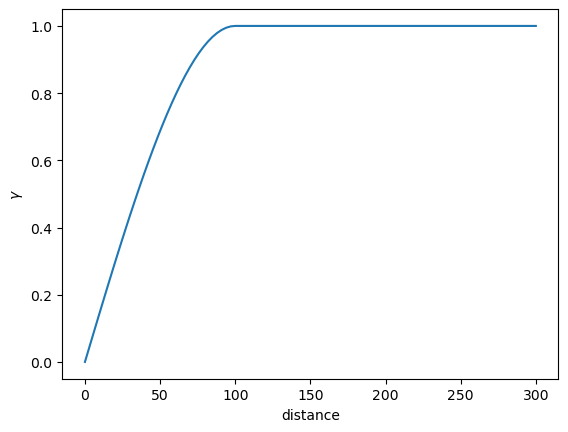

In [7]:
# spherical variogram for the spatially varying parameters
v_pp = pyemu.geostats.SphVario(
    contribution=1.0,   # sill
    a=100,              # range of correlation (metres, the model's length unit)
    anisotropy=1,       # isotropic
    bearing=0,          # angle (deg E of N) of the anisotropy ellipse; moot when isotropic
)

# geostatistical structure for the spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform="log")

pp_gs.plot()

## Tier 1 — flow: hydraulic conductivity

The first tier is flow. We parameterise hydraulic conductivity (`npf_k`) as the canonical spatially-varying property. Velocities set how fast the injected oxic, warm water reaches each monitoring point and the supply well, so K matters — but, as we will argue at the end, it is not where this case's most consequential uncertainty lives.

`flopy` writes its array files in a layout `PstFrom` does not love, so we first run a small helper (`hbd.tidy_array`) over each K file to rewrite it as a clean one-value-per-line column. We grab the K filenames by tag:

In [8]:
tag = "npf_k_"
files = hbd.get_input_filenames(tag, template_ws=template_ws, extension=".txt")

# rewrite each array file as a tidy single-column file
for f in files:
    hbd.tidy_array(template_ws / f)

# sanity check: one K array per layer, same shape as the zone array
k = np.loadtxt(template_ws / files[0])
k.shape, ib.shape

((194,), (194,))

We add K twice for each layer file: once as a field of **pilot points** (multiplier style, `par_style="m"`) so K can vary smoothly in space, and once as a single **constant** multiplier per layer so the whole field can shift up or down together. Both are bounded between 0.001 and 10 (multipliers on the model's initial K). We also register the same files as *observations* so we can later inspect the realised K fields:

In [9]:
lb, ub = 0.001, 10.0
for f in files:
    base = f.split(".")[1].replace("_", "")
    df_pp = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="pilotpoints",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,
        lower_bound=lb,
        upper_bound=ub,
        pp_options={"try_use_ppu": True,
                    "prep_hyperpars": False,
                    "pp_space": 10.},  # pilot-point spacing, in metres
    )
    df_cn = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="constant",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,
        lower_bound=lb,
        upper_bound=ub,
    )
    _ = pf.add_observations(f, prefix=base, obsgp=base)

...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'npfklayer1_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/npfklayer1_inst0pp.fac' created, factors calculated for 194 points
took 0.0066 seconds
...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'npfklayer2_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/npfklayer2_inst0pp.fac' created, factors calculated for 194 points
took 0.0020 seconds
...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'npfklayer3_inst0pp.fac'


...

INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/npfklayer11_inst0pp.fac' created, factors calculated for 194 points
took 0.0020 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'npfklayer12_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/npfklayer12_inst0pp.fac' created, factors calculated for 194 points
took 0.0020 seconds


Take a peek at the pilot-point dataframe, and plot the pilot-point locations over the grid to confirm they cover the active domain:

In [10]:
df_pp.head()

,name,x,y,zone,parval1,k,parnme,tpl,tpl_filename,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,
pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-144.10_y:0.51_zone:1,pp_0000,-144.097607,0.505934,1,1.0,0,pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-144.10_y:0.51_zone:1,~ pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-144.10_y:0.51_zone:1 ~,pst_template/npfklayer12_inst0pp.dat.tpl,pst_template/npfklayer12_inst0pp.dat,npfklayer12,1,0.0,factor,0.001,log,10.0,1.0,pilotpoints
pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-134.10_y:0.51_zone:1,pp_0001,-134.095490,0.505934,1,1.0,0,pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-134.10_y:0.51_zone:1,~ pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-134.10_y:0.51_zone:1 ~,pst_template/npfklayer12_inst0pp.dat.tpl,pst_template/npfklayer12_inst0pp.dat,npfklayer12,1,0.0,factor,0.001,log,10.0,1.0,pilotpoints
pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-124.09_y:0.51_zone:1,pp_0002,-124.093372,0.505934,1,1.0,0,pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-124.09_y:0.51_zone:1,~ pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-124.09_y:0.51_zone:1 ~,pst_template/npfklayer12_inst0pp.dat.tpl,pst_template/npfklayer12_inst0pp.dat,npfklayer12,1,0.0,factor,0.001,log,10.0,1.0,pilotpoints
pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-114.09_y:0.51_zone:1,pp_0003,-114.091255,0.505934,1,1.0,0,pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-114.09_y:0.51_zone:1,~ pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-114.09_y:0.51_zone:1 ~,pst_template/npfklayer12_inst0pp.dat.tpl,pst_template/npfklayer12_inst0pp.dat,npfklayer12,1,0.0,factor,0.001,log,10.0,1.0,pilotpoints
pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-104.09_y:0.51_zone:1,pp_0004,-104.089137,0.505934,1,1.0,0,pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-104.09_y:0.51_zone:1,~ pname:npfklayer12_inst:0_ptype:pp_pstyle:m_x:-104.09_y:0.51_zone:1 ~,pst_template/npfklayer12_inst0pp.dat.tpl,pst_template/npfklayer12_inst0pp.dat,npfklayer12,1,0.0,factor,0.001,log,10.0,1.0,pilotpoints


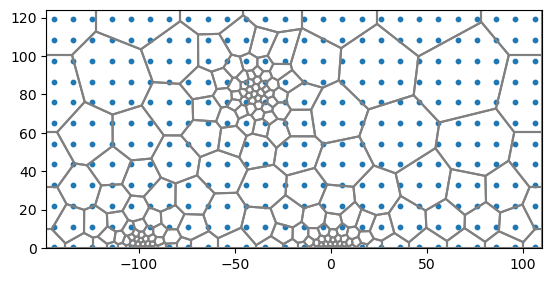

In [11]:
fig, ax = plt.subplots(1, 1)
mv = flopy.plot.PlotMapView(gwf)
mv.plot_grid()
ax.scatter(df_pp.x, df_pp.y, s=10)
ax.set_aspect("equal")

## Tier 2 — transport: porosity and dispersivity

The transport tier controls how solutes (and heat) move and spread. In MODFLOW 6, transport properties like porosity (`mst_porosity`) and longitudinal dispersivity (`dsp_alh`) are defined *separately for every transported species*. That flexibility is technically correct — species *could* differ — but for almost every practical problem it makes sense to use the **same** porosity and dispersivity for all species. We have two ways to enforce that:

1. Parameterise the property for all species and tie them together in PEST.
2. Parameterise it for *one* carrier species and copy those parameters onto the rest before each forward run.

We take option 2 — it keeps the parameter count down and is easy with a small pre-run helper. We use `h2o` as the carrier species. First, the list of species (the flow model is always first, so we skip it):

In [12]:
species = sim.model_names[1:]
species

['h2o',
 'h',
 'o',
 'charge',
 'c',
 'ca',
 'cl',
 'fe',
 'k',
 'mg',
 'n',
 'na',
 'orgc',
 's',
 'si',
 'tmp']

### Porosity

Parameterise porosity on the carrier species `h2o`, exactly as we did for K — pilot points plus a per-layer constant. The bounds here are multipliers (0.5–1.5). Porosity has a hard physical ceiling, so we also set **ultimate** bounds (`ult_ubound` / `ult_lbound`): these cap the *resulting* porosity value after the multiplier is applied, regardless of what the multiplier does. We cap it at 0.65 (comfortably below the physical max of 1, and above any realistic sand porosity) and floor it at a small positive value:

In [13]:
tag = "h2o.mst_porosity_"
files = hbd.get_input_filenames(tag, template_ws=template_ws, extension=".txt")

for f in files:
    hbd.tidy_array(template_ws / f)

lb, ub = 0.5, 1.5
ult_ub, ult_lb = 0.65, 5e-2   # cap resulting porosity at 0.65; floor near zero
for f in files:
    base = f.split(".")[1].replace("_", ".")
    df_pp = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="pilotpoints",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,
        lower_bound=lb,
        upper_bound=ub,
        ult_ubound=ult_ub,
        ult_lbound=ult_lb,
        pp_options={"prep_hyperpars": False, "pp_space": 10.},
    )
    df_cn = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="constant",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,
        lower_bound=lb,
        upper_bound=ub,
        ult_ubound=ult_ub,
        ult_lbound=ult_lb,
    )
    _ = pf.add_observations(f, prefix=base, obsgp=base)

...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'mst.porosity.layer1_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/mst.porosity.layer1_inst0pp.fac' created, factors calculated for 194 points
took 0.0021 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'mst.porosity.layer2_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...

...ppu_factor_filename 'pst_template/mst.porosity.layer11_inst0pp.fac' created, factors calculated for 194 points
took 0.0021 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!


INFO:PestUtilsLib: calculated 2D kriging factors to 'mst.porosity.layer12_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/mst.porosity.layer12_inst0pp.fac' created, factors calculated for 194 points
took 0.0022 seconds


### Dispersivity

Longitudinal dispersivity (`dsp_alh`) controls how much the injected front smears as it travels — directly relevant to the sharpness of the sulfate breakthrough at the supply well. We parameterise it on the same carrier species (`h2o`), same pilot-point + constant pattern. In the original model build this block was left commented out; we re-enable it here so the transport tier is complete.

> **Why was this block originally disabled?** A bit of tutorial archaeology: in the original model setup this dispersivity block was commented out with no explanation. Re-enabling it exposed the likely reason — the original grouped *all twelve layers* of pilot points under one parameter group, and because every layer's pilot points sit at the same plan coordinates, the prior covariance block for that group contained duplicate points and could not be inverted. The fix is simply per-layer groups (one covariance block per layer), exactly as the other tiers do. The parameterised dispersivity has since been verified with a full forward run: the template round-trips losslessly (objective function ~1e-16 on the base parameter values).

In [14]:
tag = "h2o.dsp_alh_"
files = hbd.get_input_filenames(tag, template_ws=template_ws, extension=".txt")

for f in files:
    hbd.tidy_array(template_ws / f)

lb, ub = 0.5, 10.0
for f in files:
    base = f.split(".")[1].replace("_", ".")
    df_pp = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="pilotpoints",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,   # per-layer group: one cov block per layer (lumping all layers collides identical plan coordinates -> singular cov)
        lower_bound=lb,
        upper_bound=ub,
        pp_options={"prep_hyperpars": False, "pp_space": 10.},
    )
    df_cn = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="constant",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,   # per-layer group: one cov block per layer (lumping all layers collides identical plan coordinates -> singular cov)
        lower_bound=lb,
        upper_bound=ub,
    )
    _ = pf.add_observations(f, prefix=base, obsgp=base)

...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'dsp.alh.layer1_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/dsp.alh.layer1_inst0pp.fac' created, factors calculated for 194 points
took 0.0022 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'dsp.alh.layer2_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...

INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/dsp.alh.layer11_inst0pp.fac' created, factors calculated for 194 points
took 0.0021 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'dsp.alh.layer12_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/dsp.alh.layer12_inst0pp.fac' created, factors calculated for 194 points
took 0.0020 seconds


## Tier 3 — reaction: pyrite

This is the tier that makes DIZON a *reactive*-transport problem rather than a tracer problem. Oxic water meeting pyrite drives the oxidation that releases sulfate — the forecast species. Two reaction properties plausibly dominate the sulfate forecast: how much pyrite is present (its initial mass, `m0`) and how fast it oxidises (the kinetic rate). We take them in turn.

### A note on organic matter (deliberately *not* parameterised)

The model also contains organic carbon (`Orgc`) as a kinetic phase, and it would be tempting to parameterise its initial mass too. We deliberately do **not**. In the source study ([Prommer & Stuyfzand, 2005](https://pubs.acs.org/doi/10.1021/es0486768)) organic-matter oxidation is a *minor* redox contributor relative to pyrite oxidation by O₂ and NO₃; the headline reaction is pyrite. Adding organic-matter parameters would inflate the parameter count and the prior without materially changing the sulfate forecast. This is a layered-prior judgment call: we spend our parameters where the forecast lives.

_(Aside: this section was titled "Equilibrium phases: Organic Matter" in the original setup, but the code underneath it parameterised pyrite kinetics, not organic-matter equilibrium. The heading was simply wrong. The honest title is below.)_

### Pyrite abundance (initial mass, `m0`)

The pyrite initial mass (`kinetic_phases.Pyrite.m0`) sets how much pyrite is available to react in each cell — the reservoir of sulfate. `mf6rtm` already writes these as tidy array files, so we can skip the `tidy_array` step. We parameterise it as pilot points plus a per-layer constant (here the constant uses `par_type="zone"`, equivalent to a single zone given our all-active `ib`).

> **VERIFY (ultimate bounds):** The original block set inconsistent ultimate upper bounds — `ult_ubound=15` on the pilot-point parameters but `ult_ubound=10` on the constant. There is no physical reason for the two to differ, so we pick a **single** value, `10`, for both. The choice of 10 over 15 is a judgment call (it is the tighter of the two and keeps the realised pyrite mass within the range the model was demonstrated stable over); confirm the cap against the intended prior with a test run.

In [15]:
tag = "kinetic_phases.pyrite.m0"
files = hbd.get_input_filenames(tag, template_ws=template_ws, extension=".txt")

# mf6rtm already writes these as tidy arrays, so no tidy_array() needed
lb, ub = 0.05, 5.0
ult_ub, ult_lb = 10.0, 1e-5   # single ultimate cap for both par types (see note above)
for f in files:
    base = f.split(".txt")[0].replace("_", ".").lower()
    df_pp = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="pilotpoints",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,
        lower_bound=lb,
        upper_bound=ub,
        ult_ubound=ult_ub,
        ult_lbound=ult_lb,
        pp_options={"prep_hyperpars": False, "pp_space": 10.},
    )
    df_cn = pf.add_parameters(
        f,
        zone_array=ib,
        par_type="zone",
        par_style="m",
        geostruct=pp_gs,
        par_name_base=base,
        pargp=base,
        lower_bound=lb,
        upper_bound=ub,
        ult_ubound=ult_ub,
        ult_lbound=ult_lb,
    )
    _ = pf.add_observations(f, prefix=base, obsgp=base)

...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'kinetic.phases.pyrite.m0.layer1_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/kinetic.phases.pyrite.m0.layer1_inst0pp.fac' created, factors calculated for 194 points
took 0.0020 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'kinetic.phases.pyrite.m0.layer2_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...

INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/kinetic.phases.pyrite.m0.layer11_inst0pp.fac' created, factors calculated for 194 points
took 0.0021 seconds


...pypestutils detected and being used for kriging solve, trust us, you want this!
INFO:PestUtilsLib: calculated 2D kriging factors to 'kinetic.phases.pyrite.m0.layer12_inst0pp.fac'


INFO:PestUtilsLib: all memory was freed up


...ppu_factor_filename 'pst_template/kinetic.phases.pyrite.m0.layer12_inst0pp.fac' created, factors calculated for 194 points
took 0.0022 seconds


### Pyrite oxidation rate

The pyrite *rate* — how fast pyrite oxidises once oxic water arrives — is the case's signature uncertainty, and it is strongly temperature-dependent (the paper's headline result). We would very much like it in the prior. The problem is *where* the rate lives.

**The rate itself.** Unlike K, porosity, dispersivity and pyrite `m0` — all per-cell array (`.txt`) files that `PstFrom` templates directly — the pyrite oxidation *rate* lives inside the PHREEQC `KINETICS` blocks of `phinp.dat`. Two facts make it parameterisable anyway: the `mf6rtm` runtime *reads* `phinp.dat` as-is (it does not regenerate it from the python build), and the rate law is `rate = -10.19 + parm(1) + …` with `parm(1) = log₁₀(A/V)` — **additive in log₁₀ of the rate**. One number, twelve identical `-parms` lines, a perfect global knob: shift `parm(1)` by ±1 and the rate scales by ×0.1…×10. That calls for a hand-written template file rather than an array helper — we write it right after `build_pst()` below, where the control file exists to attach it to.

## Pre- and post-processing functions

PEST++ runs the model by executing a forward-run script. Because we are doing everything in Python, `PstFrom` will write a `forward_run.py` for us; we just register the helper functions it should carry along. Some run *before* the model (e.g. copying the carrier species' transport parameters onto the other species), some are utilities used by the post-processor.

The key pre-run function is `copy_parameterized_transport_files`: it takes the porosity *and dispersivity* fields we parameterised on `h2o` and copies them onto every other transport species, so all species share the same transport properties (this is option 2 from the transport tier). With dispersivity now re-enabled, this helper copies both `mst_porosity` and `dsp_alh` — which is exactly why the dispersivity block had to be un-commented.

In [16]:
pf.extra_py_imports.append("flopy")
pf.extra_py_imports.append("shutil")

# utility functions used by the helpers below
pf.add_py_function("../herebedragons.py", "tidy_array()", is_pre_cmd=None)
pf.add_py_function("../herebedragons.py", "get_input_filenames()", is_pre_cmd=None)
pf.add_py_function("../herebedragons.py", "extract_layer_number()", is_pre_cmd=None)

# PRE-run: copy h2o's transport params (porosity + dispersivity) onto all species
pf.add_py_function("../herebedragons.py", "copy_parameterized_transport_files()", is_pre_cmd=True)

# the model command itself
pf.mod_sys_cmds.append("mf6rtm")

Run the copy once now so the template directory is internally consistent before we build the control file:

In [17]:
hbd.copy_parameterized_transport_files(ws=template_ws)

[('H2O.dsp_alh_layer1.txt', 'Tmp.dsp_alh_layer1.txt'),
 ('H2O.dsp_alh_layer10.txt', 'Tmp.dsp_alh_layer10.txt'),
 ('H2O.dsp_alh_layer11.txt', 'Tmp.dsp_alh_layer11.txt'),
 ('H2O.dsp_alh_layer12.txt', 'Tmp.dsp_alh_layer12.txt'),
 ('H2O.dsp_alh_layer2.txt', 'Tmp.dsp_alh_layer2.txt'),
 ('H2O.dsp_alh_layer3.txt', 'Tmp.dsp_alh_layer3.txt'),
 ('H2O.dsp_alh_layer4.txt', 'Tmp.dsp_alh_layer4.txt'),
 ('H2O.dsp_alh_layer5.txt', 'Tmp.dsp_alh_layer5.txt'),
 ('H2O.dsp_alh_layer6.txt', 'Tmp.dsp_alh_layer6.txt'),
 ('H2O.dsp_alh_layer7.txt', 'Tmp.dsp_alh_layer7.txt'),
 ('H2O.dsp_alh_layer8.txt', 'Tmp.dsp_alh_layer8.txt'),
 ('H2O.dsp_alh_layer9.txt', 'Tmp.dsp_alh_layer9.txt'),
 ('H2O.mst_porosity_layer1.txt', 'Tmp.mst_porosity_layer1.txt'),
 ('H2O.mst_porosity_layer10.txt', 'Tmp.mst_porosity_layer10.txt'),
 ('H2O.mst_porosity_layer11.txt', 'Tmp.mst_porosity_layer11.txt'),
 ('H2O.mst_porosity_layer12.txt', 'Tmp.mst_porosity_layer12.txt'),
 ('H2O.mst_porosity_layer2.txt', 'Tmp.mst_porosity_layer2.txt'),
 ('

## Observations and the forecast group

So far we have registered the *input arrays* as observations (handy for inspecting realised fields). Now we add the observations that matter: the simulated concentration time series. The post-processor `process_sim_conc` reads the model's cell output, maps it onto the grid, lines it up against the monitoring locations, and writes a tidy `_obs.conc.simvsmeas.csv`. We register that file's `sim` column as observations, keyed by `time`, `obsid` and `variable`.

In [18]:
pf.add_py_function("../herebedragons.py", "node_to_layer_icell2d()", is_pre_cmd=None)
pf.add_py_function("../herebedragons.py", "time_interpolate()", is_pre_cmd=None)
pf.add_py_function("../herebedragons.py", "process_sim_conc()", is_pre_cmd=False)

# bring the measured data into the template dir (the post-processor needs it to align times)
shutil.copy(Path("..", "part1_01_build_model", "model", "obs_chem_cleaned.csv"),
            template_ws / "obs_chem_cleaned.csv")

# run the post-processor once to create the obs file
fname, df = hbd.process_sim_conc(wd=template_ws)

# add the concentration observations
_ = pf.add_observations(
    fname,
    index_cols=["time", "obsid", "variable"],  # these define a unique observation
    use_cols="sim",                            # the value we track
    prefix="conc",
    obsgp="conc",
)

Processing obs for: wp1-f5


Processing obs for: wp3-f5
Processing obs for: ip2-f5


Processing obs for: wp2-f5


Processing obs for: wp4-f5


Processing obs for: welopt-ly1
Processing obs for: wp1-f4


...

Processing obs for: wp3-f1


Processing obs for: wp1-f1
Processing obs for: ip2-f1


Processing obs for: wp2-f1


Processing obs for: wp4-f1


Processed conc saved in pst_template/_obs.conc.simvsmeas.csv


Build the `Pst` control object so we have observation metadata to work with:

In [19]:
pst = pf.build_pst()
# parse the obsid/variable/time tokens out of the long obs names into columns
pst.try_parse_name_metadata()
obs = pst.observation_data
obs.shape

noptmax:0, npar_adj:15024, nnz_obs:231725


(231725, 12)

### The pyrite-rate template (the reaction tier's last knob)

As promised above: a hand-written template over `phinp.dat`. A template file is just the input file with each parameter value replaced by a `~ name ~` marker — PESTPP rewrites it with the current parameter value before every run. We mark the first `-parms` entry of each of the twelve `Pyrite` blocks with the same parameter, `pyr-lograte`:

In [20]:
import re

phinp_lines = (template_ws / "phinp.dat").read_text().split("\n")
tpl_lines, n_sub, in_pyrite = ["ptf ~"], 0, False
for ln in phinp_lines:
    if re.match(r"\s+Pyrite\s*$", ln):
        in_pyrite = True
    elif in_pyrite and "-parms" in ln:
        # the first entry is parm(1) = log10(A/V); same marker in all 12 blocks
        ln = re.sub(r"(-parms\s+)(\S+)", r"\g<1>~   pyr-lograte   ~", ln, count=1)
        n_sub += 1
        in_pyrite = False
    tpl_lines.append(ln)
(template_ws / "phinp.dat.tpl").write_text("\n".join(tpl_lines))
assert n_sub == 12, f"expected 12 Pyrite blocks, templated {n_sub}"
print(f"templated {n_sub} Pyrite -parms lines with one global parameter")

templated 12 Pyrite -parms lines with one global parameter


Attach the template to the control file and give the parameter its prior: initial value 16.0 (the base model's `parm(1)`), bounds ±1 log unit — the rate uncertain over two orders of magnitude, which is honest for a field-scale kinetic constant transplanted from literature:

In [21]:
pst.add_parameters(str(template_ws / "phinp.dat.tpl"), pst_path=".")
par = pst.parameter_data
par.loc["pyr-lograte", "parval1"] = 16.0
par.loc["pyr-lograte", "parlbnd"] = 15.0
par.loc["pyr-lograte", "parubnd"] = 17.0
par.loc["pyr-lograte", "pargp"]   = "pyr.rate"
par.loc["pyr-lograte", "partrans"] = "none"   # it IS a log quantity already
print(pst.parameter_data.loc["pyr-lograte",
      ["parval1", "parlbnd", "parubnd", "pargp", "partrans"]])

1 pars added from template file ./phinp.dat.tpl
parval1         16.0
parlbnd         15.0
parubnd         17.0
pargp       pyr.rate
partrans        none
Name: pyr-lograte, dtype: object


> **Verified, with a finding.** We tested the knob at ×10 and ×0.1 the base rate (one forward run each). The template round-trips losslessly, and the parameter genuinely moves the chemistry — monitoring-point pe shifts by up to ~16, pH by up to ~1.4 units, and the pyrite front and exchanger state move with them. But the supply-well **peak SO₄ barely notices**: across two orders of magnitude of rate, the forecast is unchanged. The peak is *mass-limited* — set by how much pyrite the oxidants can reach, not by how fast they burn it. So the rate is the kind of parameter the history data can constrain (those pH and redox signals sit well above the noise) without it driving this particular decision — pyrite *abundance* does that. Knowing which parameters carry the forecast and which merely carry the fit is half the point of the analyses ahead.

### Naming the forecast

Everything in this curriculum is judged on **one** quantity: the sulfate concentration at the **supply well** (`wellopt`) during the **supply period** (days 308–728), summarised as **peak SO₄** — the maximum over all supply-well screens and supply-period times. Treatment cost scales with that concentration, so the payoff we carry is the forecast *distribution* (median and P95), not a bright-line crossing. We name that group **now**, at the PEST-setup stage — before we have run a single ensemble — because the forecast should drive every downstream choice (what to condition on, what to emulate, what to optimise). This is the forecast-first ethos: decide what you are predicting, then build the workflow around it, not the other way round.

Our concentration observations carry `obsid`, `variable` and `time` as metadata columns. The supply well is screened over three intervals (`welopt-ly1/ly3/ly5`); the canonical forecast is the **maximum over all three screens** and all supply-period times, so the forecast group spans every one of them — the same convention every downstream notebook follows. The forecast group is the subset where the obsid is any supply-well screen, the variable is `so4`, and the time falls in the supply period. We retag those into a dedicated `forecast` group:

In [22]:
# supply period (days), forecast species and the canonical forecast screens
supply_start, supply_end = 308.0, 728.0
FORECAST_SCREENS = ["welopt-ly1", "welopt-ly3", "welopt-ly5"]   # all supply-well screens (the forecast maxes over them downstream)

# coerce the metadata columns PstFrom attached to the conc obs
obs["time"] = pd.to_numeric(obs["time"], errors="coerce")
is_supply_well = obs["obsid"].astype(str).isin(FORECAST_SCREENS)
is_so4 = obs["variable"].astype(str).str.lower() == "so4"
in_supply_period = obs["time"].between(supply_start, supply_end)

forecast_mask = is_supply_well & is_so4 & in_supply_period
obs.loc[forecast_mask, "obgnme"] = "forecast"

forecast_names = obs.loc[forecast_mask, "obsnme"].tolist()
print(f"forecast group: {len(forecast_names)} supply-well SO4 observations "
      f"across screens {FORECAST_SCREENS} over days {supply_start:.0f}-{supply_end:.0f}")

forecast group: 1263 supply-well SO4 observations across screens ['welopt-ly1', 'welopt-ly3', 'welopt-ly5'] over days 308-728


Register those observation names as PEST++ *forecasts* as well, so any predictive-uncertainty machinery downstream picks them up automatically. (They stay zero-weight observations for now — the forecast is something we *predict*, never something we condition on.)

In [23]:
pst.pestpp_options["forecasts"] = ",".join(forecast_names)

# a tidy copy of the variable name for later filtering convenience
obs["oname"] = obs["variable"]

## Drawing the prior ensemble

With the parameters and their bounds defined, we can build the **prior parameter covariance matrix** — it encodes both the per-parameter uncertainty and the spatial correlation from our variogram. We store it as a compressed binary so it stays manageable:

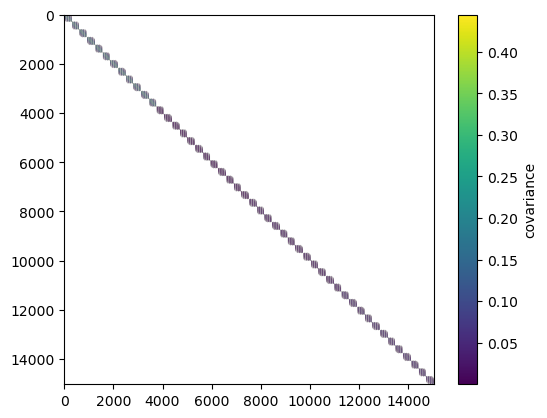

In [24]:
if pf.pst.npar < 35000:  # above ~35k params the dense cov matrix gets unwieldy
    cov = pf.build_prior(fmt="coo", filename=template_ws / "prior_cov.jcb")
    # take a peek at a slice of the matrix
    x = cov.x.copy()
    x[x == 0] = np.nan
    plt.imshow(x)
    plt.colorbar(label="covariance")

# NOTE: build_prior covers the PstFrom-managed (spatial) parameters only --
# the hand-templated pyr-lograte is not in it. With a full prior ensemble
# supplied to PESTPP-IES (below) the covariance matrix file is not needed,
# so we do not set the parcov option rather than hand-extending the matrix.

Now we *draw* the prior parameter ensemble: sample many parameter sets from that prior distribution. Each parameter set is a **realisation**; the suite of realisations is an **ensemble**. We draw **201 realisations** — this is the number carried consistently through the entire curriculum (prior MC, emulator training, history matching). We enforce parameter bounds and write the ensemble to a binary file:

In [25]:
pe = pf.draw(num_reals=201, use_specsim=False)  # draw from the prior
pe.enforce()                                     # clip to parameter bounds

# pf.draw covers the spatial fields; the rate parameter is statistically
# independent of them, so we append its column directly: normal around the
# base value, sd of half a log-unit (so the +-1 bounds sit at ~2 sd)
rate_rng = np.random.default_rng(20260606)
pe.loc[:, "pyr-lograte"] = np.clip(
    rate_rng.normal(16.0, 0.5, pe.shape[0]), 15.0, 17.0)

pe.to_binary(template_ws / "prior_pe.jcb")
pe.shape

building diagonal cov


processing  name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:100.0,anisotropy:1.0,bearing:0.0

working on pargroups ['npfklayer1']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer2']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer3']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer4']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer5']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer6']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer7']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov


working on pargroups ['npfklayer8']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer9']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer10']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer11']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['npfklayer12']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer1']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer2']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov


working on pargroups ['mst.porosity.layer3']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer4']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer5']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer6']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer7']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer8']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer9']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov


working on pargroups ['mst.porosity.layer10']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer11']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['mst.porosity.layer12']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer1']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer2']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer3']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer4']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov


working on pargroups ['dsp.alh.layer5']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer6']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer7']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer8']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer9']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer10']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['dsp.alh.layer11']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov


working on pargroups ['dsp.alh.layer12']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer1']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer2']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer3']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer4']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer5']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer6']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer7']


build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer8']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer9']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer10']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer11']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
working on pargroups ['kinetic.phases.pyrite.m0.layer12']
build cov matrix
done
getting diag var cov 312
scaling full cov by diag var cov
adding remaining parameters to diagonal


(201, 15025)

Point the control file at that ensemble and tell PESTPP-IES to use all 201 realisations. These two lines, plus the `forecasts` we set above, are the heart of the control file's PEST++ options:

In [26]:
pst.pestpp_options["ies_par_en"] = "prior_pe.jcb"
pst.pestpp_options["ies_num_reals"] = 201

## Writing the control file

There is exactly **one** canonical write of the control file, here at the end, after every parameter, observation, the forecast group and the ensemble have been set. Writing it once (rather than scattering `pst.write` calls through the notebook) means there is no ambiguity about which `pest.pst` is the real one:

In [27]:
pst.write(template_ws / "pest.pst", version=2)

noptmax:0, npar_adj:15025, nnz_obs:231725


### A test-run beat

It is good practice to do a couple of cheap sanity runs before turning anything loose at scale — this is where you catch a parameter range that breaks the model, or a template that does not round-trip. **Remember each forward run costs ~6 minutes**, so we keep this to the minimum.

First, a single deterministic run of the control file (`noptmax` defaults such that this just runs the model once on the initial parameter values). With all multipliers at 1.0 this must reproduce the base model exactly — the objective function should come back at numerical zero. If it does not, a template or instruction file is lossy and nothing downstream can be trusted:

In [28]:
pyemu.os_utils.run("pestpp-ies pest.pst", cwd=template_ws)

./pestpp-ies pest.pst




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies pest.pst'
...using serial run manager


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_02_pstfrom_setup/pst_template"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/06/26 07:49:42

processing control file pest.pst



Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1


checking model IO files...done
              starting serial run manager ...




  ---  initializing  ---  

  ---  'noptmax'=0, running control file parameter values and quitting  ---  
...saving control file parameter ensemble to  pest.base.par.csv


...

thread 0 processed 49 instruction files
06/06/26 07:55:36 done, took 0.944 seconds




-->06/06/26 07:55:37 run complete, took: 335.082 seconds
-->1 of 1 complete, 0 failed





    ---  serial run manager runs summary:  ---    
    1 of 1 complete, 0 failed
    process took : 335.082 seconds




...saving results from control file parameter value run to  pest.base.obs.csv



  ---  control file parameter phi report:  ---  
       phi type           mean            std            min            max
       measured    1.95785e-16              0    1.95785e-16    1.95785e-16
         actual    1.95785e-16              0    1.95785e-16    1.95785e-16
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.


  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group                              count  nconflict      mean       std       min       max   percent       std
kinetic.phases.pyrite.m0.layer1      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33         0
kinetic.phases.pyrite.m0.layer9      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33         0
kinetic.phases.pyrite.m0.layer8      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33         0
kinetic.phases.pyrite.m0.layer7      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33         0
kinetic.phases.pyrite.m0.layer6      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33         0
kinetic.phases.pyrite.m0.layer5      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33         0
kinetic.phases.pyrite.m0.layer4      194        194  1.63e-17         0  1.63e-17  1.63e-17      8.33   

saved par and rei files for realization BASE


pestpp-ies analysis complete...
started at 06/06/26 07:49:42
finished at 06/06/26 07:55:39
took 5.93333 minutes


Then a more rigorous load/draw check. Setting `noptmax=-2` tells PESTPP-IES to load and/or draw all the ensemble components and then run the **mean parameter ensemble vector** once. It is still a single forward run, but it exercises far more of the machinery that data assimilation will eventually lean on — a stronger sanity check than the `noptmax` default above. We write a small throwaway `test.pst` for this so the canonical `pest.pst` is never overwritten by the diagnostic:

In [29]:
pst_test = pyemu.Pst(str(template_ws / "pest.pst"))
pst_test.control_data.noptmax = -2   # load/draw all components, run the mean parameter vector once
pst_test.write(template_ws / "test.pst", version=2)
pyemu.os_utils.run("pestpp-ies test.pst", cwd=template_ws)

noptmax:-2, npar_adj:15025, nnz_obs:231725


./pestpp-ies test.pst


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies test.pst'
...using serial run manager


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "test.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_02_pstfrom_setup/pst_template"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/06/26 07:55:40

processing control file test.pst


checking model IO files...done
              starting serial run manager ...




  ---  initializing  ---  
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1
...initializing prior parameter covariance matrix
...parcov loaded  from parameter bounds, using par_sigma_range 4
...initializing observation noise covariance matrix


...obscov loaded  from observation weights


...

thread 0 processed 49 instruction files


06/06/26 08:02:48 done, took 1.198 seconds


-->06/06/26 08:02:48 run complete, took: 346.289 seconds
-->1 of 1 complete, 0 failed





    ---  serial run manager runs summary:  ---    
    1 of 1 complete, 0 failed
    process took : 346.29 seconds






...saving results from mean parameter value run to  test.mean.obs.csv



  ---  realization mean phi report:  ---  
       phi type           mean            std            min            max
         actual        174.022              0        174.022        174.022
  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group                              count  nconflict      mean       std       min       max   percent       std
conc                              221150     197738       110         0       110       110        63         0
npfklayer5                           194        194      13.4         0      13.4      13.4      7.69         0
npfklayer3                           194        194      12.5         0      12.5      12.5      7.18         0
npfklayer6                           194        194      7.39         0      7.39      7.39      4.25         0
npfklayer9                           194        194      7.28         0      7.28      7.28      4.18         0
npfklayer2          

saved par and rei files for realization mean


pestpp-ies analysis complete...
started at 06/06/26 07:55:40
finished at 06/06/26 08:02:50
took 7.16667 minutes


If you ran the test above, you can load the resulting model and plot its hydraulic conductivity and porosity fields to eyeball them — these are the **mean** of the prior parameter ensemble, a final sanity check that the layered prior produces physically sensible fields:

In [30]:
# sim_t = flopy.mf6.MFSimulation.load(sim_ws=template_ws, verbosity_level=0)
# gwf_t = sim_t.get_model("gwf")
# gwt_t = sim_t.get_model("h2o")
#
# k = gwf_t.npf.k.get_data()
# poro = gwt_t.mst.porosity.get_data()
#
# fig, axs = plt.subplots(1, 2, figsize=(6, 6), sharex=True, sharey=True)
# for ax, arr, title, label in zip(
#         axs, [np.log10(k), poro], ["H$_k$", "Porosity"],
#         ["log10(H$_k$) (m/d)", "Porosity (-)"]):
#     ax.set_aspect("equal")
#     mv = flopy.plot.PlotMapView(gwf_t, layer=6, ax=ax)
#     mv.plot_grid(lw=.5)
#     m = mv.plot_array(arr)
#     cbar = plt.colorbar(m, ax=ax, shrink=.2)
#     cbar.set_label(label, fontsize="small")
#     ax.set_title(title, fontsize="small")
#     ax.set_xticklabels([]); ax.set_yticklabels([])
# fig.tight_layout()

## Where we are

We now have a PEST interface around the DIZON model with a **layered prior**: K (flow), porosity and dispersivity (transport, the latter pending a test run), and pyrite abundance (reaction). Organic matter is excluded on purpose, and the pyrite *rate* is flagged as an open item because it is not array-templatable as the model stands. We have drawn **201** realisations and named the **forecast group** — supply-well sulfate over the supply period — before running anything, so the forecast leads the workflow.

Next, in [observations, weights and the synthetic truth](../part1_03_obs_weights_and_truth/), we enact the timeline: choose the conditioning species and their noise, switch weights off after the decision date, and pick the single prior realisation that will serve as our synthetic truth.